In [6]:
# ==============================================================================
# CELL 1: CAU HINH VA CHUAN BI DU LIEU (TIMIT + VOC)
# ==============================================================================
import os
import numpy as np
import random
import shutil
import librosa
from scipy.io import wavfile
import pandas as pd
import time
from tqdm.notebook import tqdm
import hashlib
from PIL import Image
import io

# --- CAU HINH DUONG DAN KAGGLE ---
# Input
KAGGLE_TIMIT_DIR = "/kaggle/input/darpa-timit-acousticphonetic-continuous-speech"
KAGGLE_VOC_DIR = "/kaggle/input/pascal-voc-2012"

# Output
WORKING_DIR = "/kaggle/working"
TIMIT_WAV_DIR = os.path.join(WORKING_DIR, "TIMIT_WAV_16bit")
OUTPUT_RESULT_DIR = os.path.join(WORKING_DIR, "Results_VOC")

# So luong file thuc nghiem
NUM_FILES = 1000

def prepare_data_voc(timit_root, voc_root, dest_wav, limit):
    # 1. Chuan bi Audio
    if os.path.exists(dest_wav): shutil.rmtree(dest_wav)
    os.makedirs(dest_wav)
    
    print(f"Dang quet file TIMIT tu: {timit_root}")
    all_wavs = []
    for root, _, files in os.walk(timit_root):
        for f in files:
            if f.upper().endswith(".WAV") or f.lower().endswith(".wav"):
                all_wavs.append(os.path.join(root, f))
    
    print(f"Tim thay {len(all_wavs)} file audio.")
    
    # 2. Chuan bi Anh VOC
    print(f"Dang quet file Anh VOC tu: {voc_root}")
    all_imgs = []
    for root, _, files in os.walk(voc_root):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_imgs.append(os.path.join(root, f))
                
    print(f"Tim thay {len(all_imgs)} file anh.")
    
    if not all_wavs or not all_imgs:
        print("Loi: Thieu du lieu dau vao.")
        return False, [], []

    # Chon mau ngau nhien
    selected_wavs = random.sample(all_wavs, min(limit, len(all_wavs)))
    
    # Convert Audio sang WAV chuan
    print("Dang convert Audio sang WAV 16-bit...")
    ready_wavs = []
    for src in tqdm(selected_wavs, desc="Converting"):
        try:
            y, sr = librosa.load(src, sr=None)
            y_int16 = (y * 32767).astype(np.int16)
            
            parts = src.split(os.sep)
            new_name = f"{parts[-2]}_{parts[-1]}".lower().replace(".wav", "") + ".wav"
            dst_path = os.path.join(dest_wav, new_name)
            
            wavfile.write(dst_path, sr, y_int16)
            ready_wavs.append(dst_path)
        except: pass
        
    return True, ready_wavs, all_imgs

# CHAY HAM CHUAN BI
DATA_READY, WAV_LIST, IMG_LIST = prepare_data_voc(KAGGLE_TIMIT_DIR, KAGGLE_VOC_DIR, TIMIT_WAV_DIR, NUM_FILES)

Dang quet file TIMIT tu: /kaggle/input/darpa-timit-acousticphonetic-continuous-speech
Tim thay 12600 file audio.
Dang quet file Anh VOC tu: /kaggle/input/pascal-voc-2012
Tim thay 11540 file anh.
Dang convert Audio sang WAV 16-bit...


Converting:   0%|          | 0/1000 [00:00<?, ?it/s]

In [2]:
# # ==============================================================================
# # CELL 2: HE THONG PSR-LSB & IMAGE PROCESSOR (UPDATE: HO TRO 4:2:0 SUBSAMPLING)
# # ==============================================================================
# import os
# import numpy as np
# import hashlib
# import io
# from scipy.io import wavfile
# from PIL import Image

# class ImageProcessor:
#     @staticmethod
#     def resize_to_fit(image_path, max_bytes):
#         """
#         Thu nho anh de vua voi dung luong file audio.
#         SU DUNG KY THUAT NEN 4:2:0 (Ratio 4:2:0) DE GIAM DUNG LUONG.
#         """
#         try:
#             with Image.open(image_path) as img:
#                 img = img.convert("RGB")
                
#                 # Uu tien giu kich thuoc lon (256x256) nho nén 4:2:0
#                 sizes = [256, 128, 96, 64, 48, 32] 
                
#                 for size in sizes:
#                     buffer = io.BytesIO()
#                     img_resized = img.resize((size, size))
                    
#                     # --- QUAN TRONG: THUC HIEN NEN RATIO 4:2:0 ---
#                     # subsampling=0: Tuong duong YUV 4:2:0 (Giam 50% thong tin mau)
#                     # quality=75: Chat luong trung binh kha (tuong tu bai bao)
#                     img_resized.save(buffer, format="JPEG", quality=75, subsampling=0)
                    
#                     data = buffer.getvalue()
                    
#                     if len(data) < max_bytes:
#                         # Tra ve du lieu va thong tin kich thuoc + ti le nen
#                         return data, f"{size}x{size} (4:2:0)"
#             return None, "Too Large"
#         except: return None, "Error"

# class PSR_LSB_System:
#     SENTINEL = b"||END||"
#     ANCHOR_SIZE = 1024 

#     @staticmethod
#     def _generate_seed(password, salt):
#         combined = f"{password}__{str(salt)}"
#         return int(hashlib.sha256(combined.encode()).hexdigest(), 16) % (2**32)

#     @staticmethod
#     def embed(audio_path, secret_bytes, output_path, password, n_bits=8):
#         """Nhung LSB voi n_bits"""
#         try:
#             rate, audio_data = wavfile.read(audio_path)
#             if audio_data.dtype != np.int16:
#                 audio_data = audio_data.astype(np.int16)
            
#             audio_flat = audio_data.flatten().copy()
#             full_payload = secret_bytes + PSR_LSB_System.SENTINEL
#             bits = np.unpackbits(np.frombuffer(full_payload, dtype=np.uint8))
            
#             remainder = len(bits) % n_bits
#             if remainder != 0:
#                 pad_len = n_bits - remainder
#                 bits = np.append(bits, [0] * pad_len)
            
#             powers = 1 << np.arange(n_bits)[::-1]
#             secret_values = bits.reshape(-1, n_bits).dot(powers).astype(np.int16)
            
#             capacity_slots = len(audio_flat) - PSR_LSB_System.ANCHOR_SIZE
#             if len(secret_values) > capacity_slots: return False 
            
#             salt = os.path.basename(audio_path)
#             seed = PSR_LSB_System._generate_seed(password, salt)
#             rng = np.random.default_rng(seed)
            
#             valid_range = np.arange(PSR_LSB_System.ANCHOR_SIZE, len(audio_flat))
#             shuffled_indices = rng.permutation(valid_range)
#             indices = shuffled_indices[:len(secret_values)]
            
#             mask = (1 << n_bits) - 1
#             audio_flat[indices] &= ~mask
#             audio_flat[indices] |= secret_values
            
#             wavfile.write(output_path, rate, audio_flat.reshape(audio_data.shape))
#             return True
#         except: return False

#     @staticmethod
#     def extract(stego_path, password, n_bits=8):
#         """Trich xuat LSB voi n_bits"""
#         if not os.path.exists(stego_path): return None
#         try:
#             _, stego_data = wavfile.read(stego_path)
#             stego_flat = stego_data.flatten()
            
#             salt = os.path.basename(stego_path).replace("stego_", "")
#             seed = PSR_LSB_System._generate_seed(password, salt)
#             rng = np.random.default_rng(seed)
            
#             valid_range = np.arange(PSR_LSB_System.ANCHOR_SIZE, len(stego_flat))
#             shuffled_indices = rng.permutation(valid_range)
            
#             mask = (1 << n_bits) - 1
#             extracted_values = (stego_flat[shuffled_indices] & mask).astype(np.uint8)
            
#             bits_matrix = np.unpackbits(extracted_values[:, np.newaxis], axis=1)
#             relevant_bits = bits_matrix[:, -n_bits:] 
#             bits = relevant_bits.flatten()
#             extracted_bytes = np.packbits(bits).tobytes()
            
#             pos = extracted_bytes.find(PSR_LSB_System.SENTINEL)
#             return extracted_bytes[:pos] if pos != -1 else None
#         except: return None

# class EvaluationTools:
#     @staticmethod
#     def calculate_metrics(original_path, stego_path):
#         try:
#             _, orig = wavfile.read(original_path)
#             _, stego = wavfile.read(stego_path)
#             min_len = min(len(orig), len(stego))
#             orig = orig.flatten()[:min_len].astype(float)
#             stego = stego.flatten()[:min_len].astype(float)
#             mse = np.mean((orig - stego) ** 2)
#             if mse == 0: return 0, 100, 100
#             snr = 10 * np.log10(np.mean(orig**2) / mse)
#             psnr = 10 * np.log10((32768**2) / mse)
#             return round(mse, 5), round(snr, 2), round(psnr, 2)
#         except: return -1, -1, -1

In [7]:
import os
import shutil
import random
import time
import pandas as pd
from scipy.io import wavfile
from tqdm.notebook import tqdm
from IPython.display import display

# --- CAU HINH ---
N_BITS = 8  # K=8 (Dung luong cao)

def run_experiment_full_metrics(wav_files, img_files, output_root, password):
    stego_dir = os.path.join(output_root, "Stego_Audio")
    recon_dir = os.path.join(output_root, "Recovered_Images")
    
    if os.path.exists(stego_dir): shutil.rmtree(stego_dir)
    if os.path.exists(recon_dir): shutil.rmtree(recon_dir)
    os.makedirs(stego_dir, exist_ok=True)
    os.makedirs(recon_dir, exist_ok=True)
    
    results = []
    print(f"🚀 Bat dau: k={N_BITS}, Ratio 4:2:0 (Co luu Audio MSE/PSNR)...")
    
    selected_imgs = random.choices(img_files, k=len(wav_files))
    
    for i, wav_path in enumerate(tqdm(wav_files)):
        fname = os.path.basename(wav_path)
        img_path = selected_imgs[i]
        stego_path = os.path.join(stego_dir, f"stego_{fname}")
        recon_path = os.path.join(recon_dir, f"recon_{fname}.jpg")
        
        try:
            rate_hz, audio_data = wavfile.read(wav_path)
            duration = len(audio_data) / rate_hz
            
            num_samples = len(audio_data.flatten())
            
            # Capacity k=8
            max_payload_bytes = ((num_samples - 1024) * N_BITS) // 8
            safe_payload = max_payload_bytes - 512
            
            # Resize & Nen 4:2:0
            img_bytes, size_str = ImageProcessor.resize_to_fit(img_path, safe_payload)
            
            if img_bytes:
                # Embed
                if PSR_LSB_System.embed(wav_path, img_bytes, stego_path, password, n_bits=N_BITS):
                    # Extract
                    extracted = PSR_LSB_System.extract(stego_path, password, n_bits=N_BITS)
                    
                    if extracted:
                        with open(recon_path, "wb") as f: f.write(extracted)
                    
                    # --- TINH TOAN METRICS (Audio) ---
                    # Ham calculate_metrics tra ve: mse, snr, psnr
                    mse, snr, psnr = EvaluationTools.calculate_metrics(wav_path, stego_path)
                    
                    status = "Success" if extracted == img_bytes else "Mismatch"
                    payload_kb = len(img_bytes) / 1024
                    rate_kbps = payload_kb / duration if duration > 0 else 0
                    
                    results.append({
                        "File": fname,
                        "k": f"{N_BITS}",
                        "Ratio": "4:2:0",
                        "Audio MSE": mse,       # <--- MOI: Luu MSE
                        "Audio PSNR": psnr,     # <--- MOI: Luu PSNR
                        "Audio SNR": snr,
                        "Image Size": size_str,
                        "Rate(kBps)": round(rate_kbps, 2),
                        "Status": status
                    })
        except Exception: pass

    # --- TONG HOP KET QUA ---
    df = pd.DataFrame(results)
    if not df.empty:
        success_df = df[df['Status'] == 'Success'].copy()
        
        if not success_df.empty:
            # Tinh trung binh tat ca cac cot
            avg_row = {
                "File": "AVERAGE",
                "k": f"{N_BITS}",
                "Ratio": "4:2:0",
                "Audio MSE": round(success_df["Audio MSE"].mean(), 5),   # TB MSE
                "Audio PSNR": round(success_df["Audio PSNR"].mean(), 2), # TB PSNR
                "Audio SNR": round(success_df["Audio SNR"].mean(), 2),   # TB SNR
                "Image Size": "Mixed",
                "Rate(kBps)": round(success_df["Rate(kBps)"].mean(), 2),
                "Status": "Summary"
            }
            
            final_df = pd.concat([success_df, pd.DataFrame([avg_row])], ignore_index=True)
            
            # Sap xep lai thu tu cot cho dep
            cols = ["File", "k", "Ratio", "Audio MSE", "Audio PSNR", "Audio SNR", "Rate(kBps)", "Image Size", "Status"]
            final_df = final_df[cols]
            
            print(f"\n=== KET QUA CHI TIET (k={N_BITS}) ===")
            display(pd.concat([final_df.head(5), final_df.tail(1)]))
            
            # Luu file
            csv_name = f"Full_Metrics_k{N_BITS}_420.csv"
            csv_path = os.path.join(output_root, csv_name)
            final_df.to_csv(csv_path, index=False)
            
            shutil.make_archive(f"/kaggle/working/Final_Result", 'zip', output_root)
            print(f"Da luu bang so lieu: {csv_name}")
            print(f"Tai file zip: Final_Result.zip")
    else:
        print("Khong co ket qua nao.")

# --- CHAY ---
PASSWORD = "NgocChien"
if DATA_READY:
    run_experiment_full_metrics(WAV_LIST, IMG_LIST, OUTPUT_RESULT_DIR, PASSWORD)

🚀 Bat dau: k=8, Ratio 4:2:0 (Co luu Audio MSE/PSNR)...


  0%|          | 0/1000 [00:00<?, ?it/s]


=== KET QUA CHI TIET (k=8) ===


,File,k,Ratio,Audio MSE,Audio PSNR,Audio SNR,Rate(kBps),Image Size,Status
0,mkdr0_sx283.wav,8,4:2:0,6849.07827,51.95,8.52,7.57,256x256 (4:2:0),Success
1,msrg0_sx321.wav,8,4:2:0,3710.25667,54.61,19.91,4.51,256x256 (4:2:0),Success
2,mhxl0_sx332.wav,8,4:2:0,5234.07620,53.12,20.67,5.82,256x256 (4:2:0),Success
3,mdem0_sa2.wav,8,4:2:0,2672.58013,56.04,26.22,2.92,256x256 (4:2:0),Success
4,msfh1_si1900.wav,8,4:2:0,2505.89922,56.32,17.26,2.99,256x256 (4:2:0),Success
1000,AVERAGE,8,4:2:0,4709.41865,53.93,16.39,5.40,Mixed,Summary


Da luu bang so lieu: Full_Metrics_k8_420.csv
Tai file zip: Final_Result.zip


 Dang kiem tra file: stego_msrr0_si1761.wav
--------------------------------------------------
 1. Nghe thu file da giau tin (LSB-8):


 2. Dang trich xuat voi Mat khau='NgocChien' va LSB-8...
    Trich xuat thanh cong! (8286 bytes)
    Thoi gian: 0.0043s


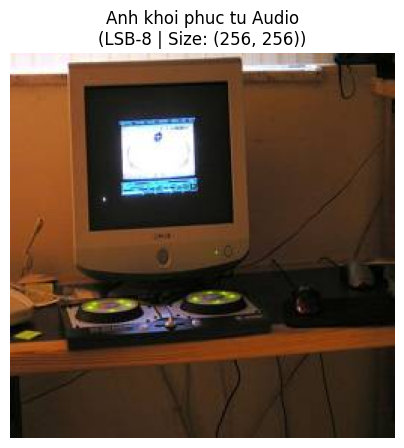

📏 Kich thuoc anh goc: (256, 256)


In [9]:
# ==============================================================================
# CELL 4: KIEM TRA NGAU NHIEN (CAP NHAT CHO K=8)
# ==============================================================================
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import random
import os
import io
from PIL import Image

# --- CAU HINH KIEM TRA (LUU Y PHAI KHOP CELL 3) ---
OUTPUT_ROOT = "/kaggle/working/Results_VOC" 
STEGO_DIR = os.path.join(OUTPUT_ROOT, "Stego_Audio")

# QUAN TRONG: Phai giong y het Cell 3
PASSWORD = "NgocChien" 
N_BITS_CHECK = 8  # <--- Phai la 8 vi ban vua chay thuc nghiem k=8

def check_random_result():
    if not os.path.exists(STEGO_DIR):
        print("Loi: Chua co thu muc ket qua. Hay chay Cell 3 truoc.")
        return

    # 1. Lay danh sach file
    stego_files = [f for f in os.listdir(STEGO_DIR) if f.endswith('.wav')]
    
    if not stego_files:
        print("Khong tim thay file Stego nao.")
        return

    # 2. Chon ngau nhien
    target_file = random.choice(stego_files)
    stego_path = os.path.join(STEGO_DIR, target_file)
    
    print(f" Dang kiem tra file: {target_file}")
    print("-" * 50)

    # 3. Nghe thu (Voi k=8 se nghe thay tieng 'xi' nen ro hon k=1)
    print(f" 1. Nghe thu file da giau tin (LSB-{N_BITS_CHECK}):")
    display(Audio(stego_path))

    # 4. Trich xuat
    print(f" 2. Dang trich xuat voi Mat khau='{PASSWORD}' va LSB-{N_BITS_CHECK}...")
    start_t = time.time()
    
    # Goi ham extract voi n_bits=8
    extracted_bytes = PSR_LSB_System.extract(stego_path, PASSWORD, n_bits=N_BITS_CHECK)
    
    if extracted_bytes:
        print(f"    Trich xuat thanh cong! ({len(extracted_bytes)} bytes)")
        print(f"    Thoi gian: {time.time() - start_t:.4f}s")
        
        # 5. Hien thi Anh
        try:
            img = Image.open(io.BytesIO(extracted_bytes))
            plt.figure(figsize=(5, 5)) # Tang size hien thi vi anh 256x256 dep hon
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Anh khoi phuc tu Audio\n(LSB-{N_BITS_CHECK} | Size: {img.size})")
            plt.show()
            print(f"📏 Kich thuoc anh goc: {img.size}")
        except Exception as e:
            print(f"❌ Loi hien thi anh: {e}")
            print("   (Co the sai mat khau hoac du lieu bi hong)")
    else:
        print("❌ Loi: Khong trich xuat duoc.")
        print(f"   (Kiem tra lai Mat khau hoac so bit n_bits co phai la {N_BITS_CHECK} khong?)")

# Chay kiem tra
check_random_result()